<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L1_RNNs_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=jPqmZSfr9_w) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P01.pdf)

In [1]:
# Week 7, Lecture 1: RNN's Intro
from IPython.display import HTML, display

VIDEO_ID = "jPqmZSfr9_w"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 1: Recurrent Neural Networks — An Introduction

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.1 Introduction to RNNs**.

**What you will learn**

- Why fixed-size, independent inputs are the wrong model for sequences.
- The recurrence $h_t = \tanh(Ux_t + Wh_{t-1})$, and why the *same* parameters are reused at every step.
- Computational graphs: how a derivative is a sum over paths, and how autograd builds the graph as you go.
- The four RNN shapes — one-to-one, one-to-many, many-to-one, many-to-many — as concrete tensor traces.
- A character-level language model on the vocabulary `[h, e, l, o]`, built end to end.

**Contents**

1. Why sequences break the feedforward assumption
2. The recurrence, and weight sharing across time
3. Computational graphs
4. The four RNN shapes
5. A character-level language model
6. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

Week 6 closed the convolutional part of the course: detection with boxes, then segmentation
per pixel. Every model so far took a **fixed-size** input and treated each input as
**independent** of the last. This week drops both assumptions.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Why sequences break the feedforward assumption

A CNN for image classification takes a fixed-size input, say $32 \times 32$, and produces
one label. Feed it two images in a row and the two computations are entirely independent:
nothing about the first influences the second.

Now think about text auto-completion. Three things change at once:

- successive inputs are **no longer independent** — what you typed matters for what comes next,
- the number of inputs and the number of predictions are **not fixed**,
- the model performs the **same task at every position** (input: a character, output: a character).

These are **sequence learning problems**, and they need a model with memory.

In [3]:
# A feedforward layer has no memory: shuffle the inputs and each output is unchanged.
lin = nn.Linear(4, 3, bias=False)
xs = torch.randn(5, 4)                       # five independent inputs

out_in_order = torch.stack([lin(x) for x in xs])
out_shuffled = torch.stack([lin(x) for x in xs[torch.randperm(5)]])

# Every row of the shuffled output is still a row of the original: order carried no information.
matched = sum(any(torch.allclose(a, b, atol=1e-6) for b in out_in_order) for a in out_shuffled)
print(f'rows of the shuffled output found in the original: {matched}/5')
print('a feedforward layer is order-blind: the sequence itself carries no information')

rows of the shuffled output found in the original: 5/5
a feedforward layer is order-blind: the sequence itself carries no information


## 2. The recurrence, and weight sharing across time

The fix is an **internal state** that is updated as the sequence is processed:

$$h_t = f_{UW}(x_t,\, h_{t-1})$$

where $h_t$ is the new state, $h_{t-1}$ the old state, $x_t$ the input at this step, and
$f_{UW}$ a function with parameters $U$ and $W$. The **simple** (or *vanilla*, or *Elman*)
RNN takes the state to be a single hidden vector:

$$h_t = \tanh\!\left(U x_t + W h_{t-1}\right), \qquad y_t = \mathrm{softmax}\!\left(V h_t\right)$$

The point the slides put in red is worth repeating: **the same function and the same set of
parameters are used at every time step.** That is what lets one model handle a sequence of
any length.

In [4]:
# The recurrence, written out as a loop. Note U, W, V are created once and reused.
D, H, V_out = 4, 3, 4                        # input dim, hidden dim, output dim

U = torch.randn(H, D) * 0.3                  # input -> hidden
W = torch.randn(H, H) * 0.3                  # hidden -> hidden
V = torch.randn(V_out, H) * 0.3              # hidden -> output

def rnn_forward(xs, h0=None):
    h = torch.zeros(H) if h0 is None else h0
    hs, ys = [], []
    for x in xs:
        h = torch.tanh(U @ x + W @ h)        # the same U, W at every step
        hs.append(h)
        ys.append(torch.softmax(V @ h, dim=0))
    return torch.stack(hs), torch.stack(ys)

xs = torch.randn(6, D)
hs, ys = rnn_forward(xs)
print(f'input  {tuple(xs.shape)}  ->  hidden {tuple(hs.shape)}  ->  output {tuple(ys.shape)}')
print(f'every output row sums to 1: {torch.allclose(ys.sum(1), torch.ones(6))}')

input  (6, 4)  ->  hidden (6, 3)  ->  output (6, 4)
every output row sums to 1: True


In [5]:
# Weight sharing means the parameter count does not depend on the sequence length.
for T in (5, 50, 500):
    xs_T = torch.randn(T, D)
    hs_T, _ = rnn_forward(xs_T)
    print(f'  T = {T:3d}  ->  {hs_T.shape[0]:3d} hidden states, '
          f'still {U.numel() + W.numel() + V.numel()} parameters')

print(f'\nU {tuple(U.shape)} + W {tuple(W.shape)} + V {tuple(V.shape)} = '
      f'{U.numel()} + {W.numel()} + {V.numel()} = {U.numel() + W.numel() + V.numel()} weights, for any T')

  T =   5  ->    5 hidden states, still 33 parameters
  T =  50  ->   50 hidden states, still 33 parameters
  T = 500  ->  500 hidden states, still 33 parameters

U (3, 4) + W (3, 3) + V (4, 3) = 12 + 9 + 12 = 33 weights, for any T


## 3. Computational graphs

Backpropagation through an RNN is easier to think about as a graph. A **computational
graph** is a directed graph whose nodes are operations and variables, and whose edges carry
tensors.

Take $e = (a+b)*(b+1)$, with $c = a+b$ and $d = b+1$, so $e = c*d$. At $a=2, b=1$ we get
$c=3$, $d=2$, $e=6$.

To differentiate, label each edge with a local derivative and then **sum over all paths from
one node to the other, multiplying the derivatives along each path.** Here $b$ reaches $e$
by two routes, through $c$ and through $d$:

$$\frac{\partial e}{\partial b} = 1 \cdot 2 + 1 \cdot 3 = 5$$

In [6]:
# Build the graph by hand, then let autograd confirm the path-sum answer.
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
c = a + b
d = b + 1
e = c * d
e.backward()

print(f'  c = a + b = {c.item():.0f},  d = b + 1 = {d.item():.0f},  e = c * d = {e.item():.0f}')
print(f'  de/da = {a.grad.item():.0f}   (one path: dc/da * de/dc = 1 * 2)')
print(f'  de/db = {b.grad.item():.0f}   (two paths: 1*2 through c, plus 1*3 through d)')

assert e.item() == 6 and a.grad.item() == 2 and b.grad.item() == 5, 'path sum disagrees with autograd'
print('\nthe slide arithmetic and autograd agree')

  c = a + b = 3,  d = b + 1 = 2,  e = c * d = 6
  de/da = 2   (one path: dc/da * de/dc = 1 * 2)
  de/db = 5   (two paths: 1*2 through c, plus 1*3 through d)

the slide arithmetic and autograd agree


## 4. The four RNN shapes

The same recurrence supports several input/output patterns. The differences are entirely in
*where you read outputs from* and *what you feed in*:

| Shape | Example |
|---|---|
| one to one | a vanilla neural network, no recurrence needed |
| one to many | **image captioning** — one image, a sequence of words |
| many to one | **action prediction** — a sequence of frames, one action label |
| many to many (staggered) | **video captioning** — frames in, a caption out |
| many to many (aligned) | **frame-level video classification** |

In [7]:
# Each shape as a tensor trace, using the same recurrence underneath.
T = 6

hs, ys = rnn_forward(torch.randn(T, D))
print(f'many-to-many (aligned) : {T} inputs -> {ys.shape[0]} outputs   {tuple(ys.shape)}')

print(f'many-to-one            : {T} inputs -> 1 output    {tuple(ys[-1].shape)}  (read the last state only)')

# one-to-many: one real input, then zeros (or the previous output) at later steps
x0 = torch.randn(D)
seq = torch.cat([x0[None, :], torch.zeros(T - 1, D)])
_, ys_om = rnn_forward(seq)
print(f'one-to-many            : 1 input  -> {ys_om.shape[0]} outputs   {tuple(ys_om.shape)}')

losses = torch.stack([-torch.log(y[0] + 1e-9) for y in ys])     # a per-step loss
print(f'\nper-step losses {tuple(losses.shape)} aggregate into one scalar L = {losses.sum():.4f}')

many-to-many (aligned) : 6 inputs -> 6 outputs   (6, 4)
many-to-one            : 6 inputs -> 1 output    (4,)  (read the last state only)
one-to-many            : 1 input  -> 6 outputs   (6, 4)

per-step losses (6,) aggregate into one scalar L = 7.9922


## 5. A character-level language model

The slides' example uses the vocabulary `[h, e, l, o]` and the training sequence `hello`.
The input at each step is a one-hot vector of length 4, the hidden state has 3 units, and
the output layer scores the 4 characters. At test time you sample a character and feed it
back in as the next input.

With $W_{xh} \in \mathbb{R}^{3\times4}$, $W_{hh} \in \mathbb{R}^{3\times3}$ and
$W_{hy} \in \mathbb{R}^{4\times3}$, that is $12 + 9 + 12 = 33$ weights.

In [8]:
# The char-level model from the slides, trained on the single word "hello".
vocab = ['h', 'e', 'l', 'o']
stoi = {c: i for i, c in enumerate(vocab)}
Vsz, Hsz = len(vocab), 3

Wxh = torch.randn(Hsz, Vsz, requires_grad=True)
Whh = torch.randn(Hsz, Hsz, requires_grad=True)
Why = torch.randn(Vsz, Hsz, requires_grad=True)
with torch.no_grad():
    for p in (Wxh, Whh, Why): p *= 0.3

print(f'parameters: {Wxh.numel()} + {Whh.numel()} + {Why.numel()} = '
      f'{Wxh.numel() + Whh.numel() + Why.numel()} weights')

def onehot(ch):
    v = torch.zeros(Vsz); v[stoi[ch]] = 1.0; return v

inputs, targets = 'hell', 'ello'
opt = torch.optim.Adam([Wxh, Whh, Why], lr=0.1)
for step in range(300):
    h = torch.zeros(Hsz); loss = 0.0
    for ch, tgt in zip(inputs, targets):
        h = torch.tanh(Wxh @ onehot(ch) + Whh @ h)
        logits = Why @ h
        loss = loss + nn.functional.cross_entropy(logits[None, :], torch.tensor([stoi[tgt]]))
    opt.zero_grad(); loss.backward(); opt.step()

print(f'loss after training: {loss.item():.4f}')

parameters: 12 + 9 + 12 = 33 weights


loss after training: 0.0026


In [9]:
# Sample from the trained model, feeding each output back in as the next input.
with torch.no_grad():
    h = torch.zeros(Hsz)
    ch = 'h'
    generated = ch
    for _ in range(4):
        h = torch.tanh(Wxh @ onehot(ch) + Whh @ h)
        probs = torch.softmax(Why @ h, dim=0)
        ch = vocab[int(probs.argmax())]
        generated += ch

print(f'seeded with "h", the model generates: {generated}')
print(f'target sequence was:                  hello')

seeded with "h", the model generates: hello
target sequence was:                  hello


## 6. Explore and verify

Two claims are worth checking rather than trusting: that our hand-written loop is exactly
what `nn.RNN` computes, and that the parameter count really is independent of sequence
length. The slides also contain a softmax column that does not add up, which is worth
recomputing.

In [10]:
# Verify the recurrence and the weight-sharing claim.

# 1. Our loop == nn.RNN. The slides write no bias terms, so build the module with bias=False.
ref = nn.RNN(input_size=D, hidden_size=H, nonlinearity='tanh', bias=False, batch_first=True)
with torch.no_grad():
    ref.weight_ih_l0.copy_(U)
    ref.weight_hh_l0.copy_(W)

xs_test = torch.randn(7, D)
ours, _ = rnn_forward(xs_test)
theirs, _ = ref(xs_test[None])
assert torch.allclose(ours, theirs[0], atol=1e-6), 'hand-written loop disagrees with nn.RNN'

# 2. Parameter count does not grow with T.
counts = {T: sum(p.numel() for p in nn.RNN(D, H, bias=False).parameters()) for T in (10, 100, 1000)}
assert len(set(counts.values())) == 1, 'parameter count changed with sequence length'

# 3. The slides' first softmax column. Recompute it.
logits = torch.tensor([1.0, 2.2, -3.0, 4.1])
slide  = torch.tensor([0.03, 0.84, 0.00, 0.13])
actual = torch.softmax(logits, dim=0)

print(f'  loop vs nn.RNN, max |difference| = {(ours - theirs[0]).abs().max():.2e}')
print(f'  parameters at T = 10/100/1000   = {list(counts.values())}')
print(f'\n  logits            {logits.tolist()}')
print(f'  slide prints      {[round(v, 2) for v in slide.tolist()]}')
print(f'  actual softmax    {[round(v, 2) for v in actual.tolist()]}')
print('  -> the slide column is permuted; the largest logit (4.1) must get the largest probability')

  loop vs nn.RNN, max |difference| = 5.96e-08
  parameters at T = 10/100/1000   = [21, 21, 21]

  logits            [1.0, 2.200000047683716, -3.0, 4.099999904632568]
  slide prints      [0.03, 0.84, 0.0, 0.13]
  actual softmax    [0.04, 0.13, 0.0, 0.84]
  -> the slide column is permuted; the largest logit (4.1) must get the largest probability


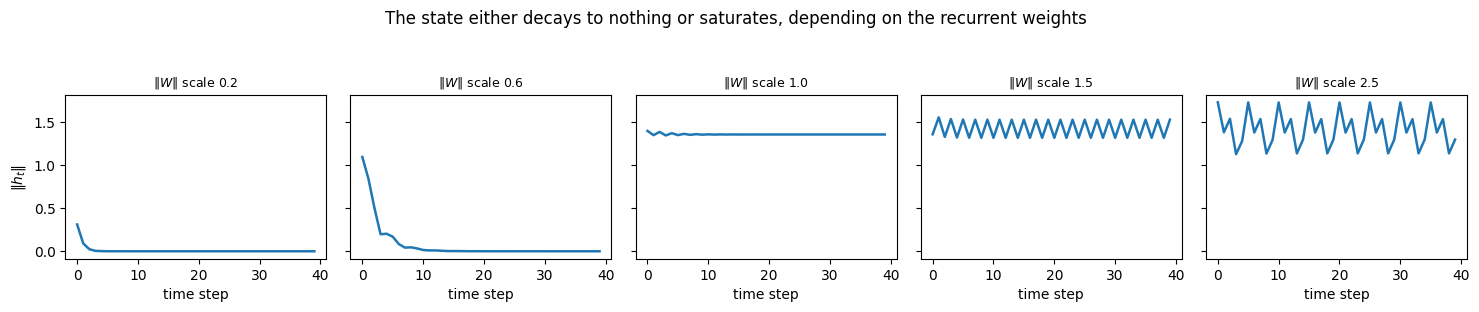

In [11]:
# Static sweep: how fast does the hidden state forget its initial value?
fig, ax = plt.subplots(1, 5, figsize=(15, 2.9), sharey=True)
for a, scale in zip(ax, [0.2, 0.6, 1.0, 1.5, 2.5]):
    Ws = torch.randn(H, H) * scale
    h = torch.ones(H)
    norms = []
    for t in range(40):
        h = torch.tanh(Ws @ h)
        norms.append(h.norm().item())
    a.plot(norms, lw=1.8)
    a.set_title(f'$\\|W\\|$ scale {scale}', fontsize=9)
    a.set_xlabel('time step')
ax[0].set_ylabel('$\\|h_t\\|$')
fig.suptitle('The state either decays to nothing or saturates, depending on the recurrent weights', y=1.06)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [12]:
# Live: the scale of W decides whether memory decays or saturates.
from ipywidgets import interact, FloatSlider, IntSlider

def memory(scale=1.0, steps=40):
    torch.manual_seed(0)
    Ws = torch.randn(H, H) * scale
    h = torch.ones(H)
    norms = []
    for _ in range(steps):
        h = torch.tanh(Ws @ h)
        norms.append(h.norm().item())
    fig, a = plt.subplots(figsize=(7, 3.2))
    a.plot(norms, lw=2)
    a.set_xlabel('time step'); a.set_ylabel('$\\|h_t\\|$')
    a.set_title(f'recurrent weight scale = {scale:.2f}')
    plt.tight_layout(); plt.show()

interact(memory, scale=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.0),
                 steps=IntSlider(min=10, max=100, step=10, value=40));

interactive(children=(FloatSlider(value=1.0, description='scale', max=3.0, min=0.1), IntSlider(value=40, descr…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Sequence problems** | Inputs are dependent, of variable length, and the same task runs at every position |
| **Internal state** | $h_t = f_{UW}(x_t, h_{t-1})$: the state carries everything the model remembers |
| **Simple RNN** | $h_t = \tanh(Ux_t + Wh_{t-1})$, $y_t = \mathrm{softmax}(Vh_t)$; also called vanilla or Elman |
| **Weight sharing** | One set of $U, W, V$ is reused at every step, so parameter count is independent of $T$ |
| **Computational graph** | A derivative is a sum over paths, multiplying local derivatives along each |
| **Shapes** | one-to-one, one-to-many, many-to-one, many-to-many; the recurrence is the same in all |
| **Char-level LM** | One-hot in, softmax out, sample and feed back; 33 weights for a 4-character vocabulary |

## Exercises

1. **Can an RNN have more than one hidden layer?** Stack a second recurrence on top of the first, so the hidden sequence of layer 1 becomes the input sequence of layer 2. Verify against `nn.RNN(..., num_layers=2)` and report how the parameter count changes.
2. **Morphing the state too much.** The state records information from all previous steps, morphed a little by each new input. Scale $W$ up until the state saturates within three steps, and describe what the model can no longer represent.
3. **Fix the slide.** Recompute all four softmax columns of the character-level example and identify which two do not match what is printed. What is the giveaway, without doing any arithmetic?
4. **One-to-many, properly.** The version above feeds zeros after the first step. Change it to feed the previous *output* back in as the next input, and describe how that changes what the model can generate.
